Accuracy: 0.905

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.91      1.00      0.95       543

    accuracy                           0.91       600
   macro avg       0.45      0.50      0.48       600
weighted avg       0.82      0.91      0.86       600



c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


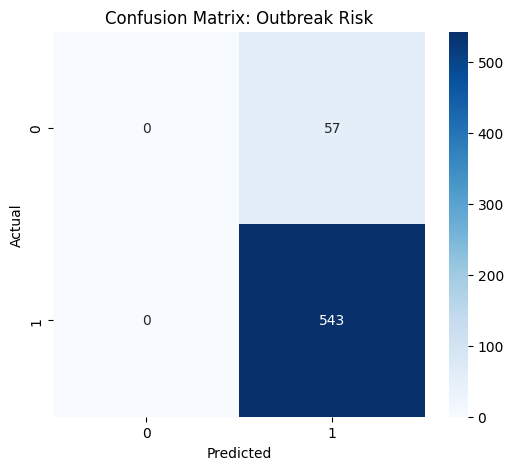

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\LIGHTRQX\Downloads\water_pollution_disease.csv")

# ----------------------------
# Feature Engineering
# ----------------------------
# Unsafe thresholds
df["Unsafe_Nitrate"] = (df["Nitrate Level (mg/L)"] > 10).astype(int)
df["Unsafe_Lead"] = (df["Lead Concentration (µg/L)"] > 10).astype(int)
df["Unsafe_Bacteria"] = (df["Bacteria Count (CFU/mL)"] > 1000).astype(int)
df["High_Turbidity"] = (df["Turbidity (NTU)"] > 5).astype(int)
df["Extreme_pH"] = ((df["pH Level"] < 6.5) | (df["pH Level"] > 8.5)).astype(int)

# Aggregate sanitation/water/population risk
df["Sanitation_Gap"] = 100 - df["Sanitation Coverage (% of Population)"]
df["Water_Access_Gap"] = 100 - df["Access to Clean Water (% of Population)"]
df["Treatment_Score"] = df["Unsafe_Nitrate"] + df["Unsafe_Lead"] + df["Unsafe_Bacteria"]
df["Effective_Clean_Water"] = df["Water_Access_Gap"] + df["Sanitation_Gap"] + df["Treatment_Score"]
df["Urban_Pressure"] = df["Urbanization Rate (%)"] * df["Population Density (people per km²)"] / 1000
df["Rainfall_Temp_Interaction"] = df["Rainfall (mm per year)"] * df["Temperature (°C)"]

# ----------------------------
# Target Engineering
# ----------------------------
# Binary risk: High risk if Diarrheal cases > 200 OR Cholera > 20 OR Typhoid > 50
df["Outbreak_Risk"] = (
    (df["Diarrheal Cases per 100,000 people"] > 200) |
    (df["Cholera Cases per 100,000 people"] > 20) |
    (df["Typhoid Cases per 100,000 people"] > 50)
).astype(int)

# ----------------------------
# Features and Target
# ----------------------------
X = df.drop(columns=[
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people",
    "Outbreak_Risk"
])
y = df["Outbreak_Risk"]

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# ----------------------------
# Preprocessing
# ----------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# ----------------------------
# Model
# ----------------------------
rf = RandomForestClassifier(random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

# ----------------------------
# Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# Hyperparameter Tuning (Optional)
# ----------------------------
param_grid = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

# ----------------------------
# Predict & Evaluate
# ----------------------------
y_pred = grid.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Outbreak Risk")
plt.show()


c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\LIGHTRQX\langmodel_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


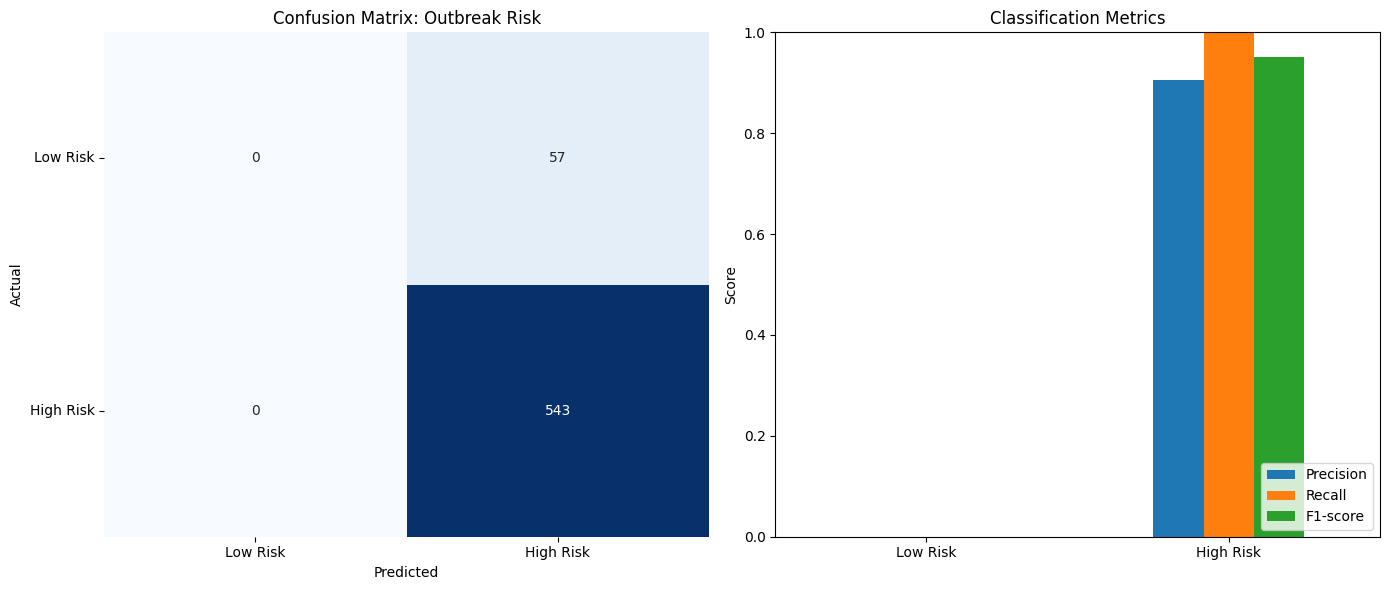

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_labels = ["Low Risk", "High Risk"]

# Create classification report
report = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report).transpose().iloc[:-3, :3]  # exclude avg rows
metrics_df.index = ["Low Risk", "High Risk"]

# Figure layout
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 1️⃣ Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix: Outbreak Risk")
axes[0].set_xticklabels(cm_labels)
axes[0].set_yticklabels(cm_labels, rotation=0)

# 2️⃣ Precision/Recall/F1
metrics_df.plot(kind='bar', ax=axes[1], color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[1].set_title("Classification Metrics")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0,1)
axes[1].legend(["Precision", "Recall", "F1-score"], loc="lower right")
axes[1].set_xticklabels(metrics_df.index, rotation=0)

plt.tight_layout()
plt.show()
